##### <font color=#A0A0A0>
##### ════════════════════════════════════════════════════════
#####     📊 **WEB SCRAPING DE PRECIO DE APARTAMENTOS EN FINCA RAIZ**
##### ════════════════════════════════════════════════════════ </font>

#### 🎯 Project Objetive
Hacer predicciones de precio usando tecnicas de regresion para ayudar a compradores y vendedores a tomar decisiones mas informadas

In [1]:
#Import de paquetes usados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV,LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from xgboost import XGBRegressor, plot_importance
import statsmodels.api as sm
import folium
import branca.colormap as cm
import geopandas as gpd
from shapely.geometry import Point
import json
pd.set_option('display.max_rows', None)

SyntaxError: source code string cannot contain null bytes (<string>)

In [ ]:
#Carga de datos
data = pd.read_csv("../data/Real_State_Bogota.csv")
data.head()


,longitude,latitude,stratum,bathrooms,constructed_area,house_age,bedrooms,parking,administration,floor,rent_price,facilities
0,-74.048398,4.700991,5.0,2.0,97.0,12.0,2.0,2.0,0.0,0.0,4500000.0,[]
1,-74.055693,4.687506,6.0,1.0,42.0,12.0,1.0,1.0,0.0,5.0,2800000.0,"['Ascensor', 'Balcón', 'Caldera', 'Calentador'..."
2,-74.052512,4.675927,6.0,4.0,116.0,23.0,4.0,2.0,0.0,7.0,5500000.0,"['Baño Auxiliar', 'Calentador', 'Chimenea', 'C..."
3,-74.049210,4.672860,5.0,3.0,138.0,23.0,3.0,2.0,0.0,4.0,8000000.0,"['Acceso Pavimentado', 'Amoblado', 'Ascensor',..."
4,-74.050727,4.700429,5.0,2.0,78.0,23.0,3.0,1.0,0.0,3.0,4000000.0,"['Acceso Pavimentado', 'Ascensor', 'Baño Indep..."


#### <font color=#A0A0A0>📈 **Analisis Exploratorio de datos**</font>

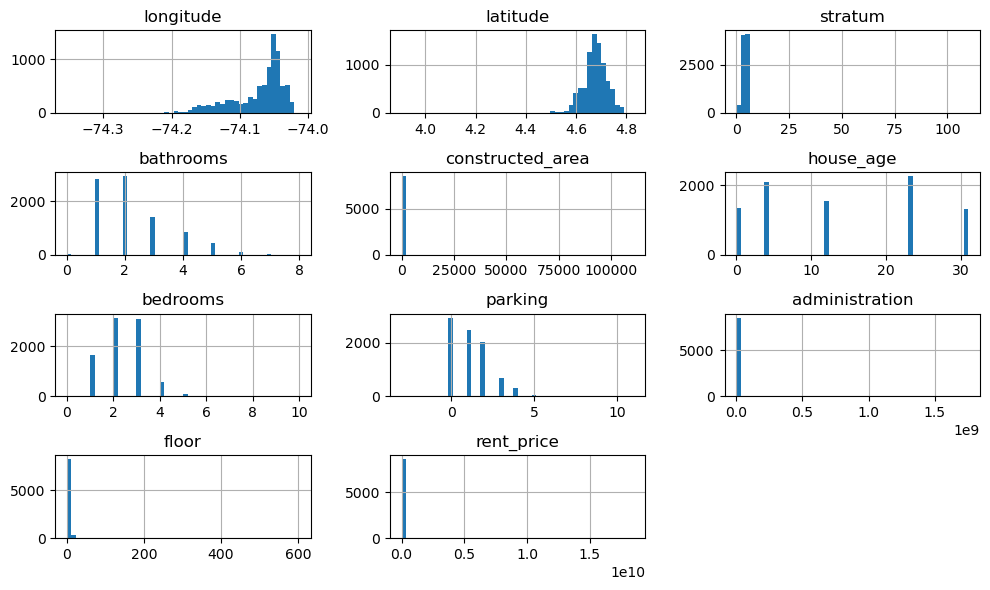

In [ ]:
#Graficas de distribución de los features obtenidos, esto es bueno para identificar outliers o comportamientos raros en los datos
data.hist(bins=50, figsize=(10,6))
plt.tight_layout()
plt.show()

In [ ]:
#Eliminación de valores nulos
data = data.dropna()

In [ ]:
# Las variables longitude y latitude son fundamentales que se encuentren dentro del area que corresponde a Bogota, 
# el siguiente codigo descarta apartamentos fuera del area correspondiente a Bogota.
data = data[(data['latitude']>=4.45)&(data['latitude']<=4.83)]
data = data[(data['longitude']>=-74.25)&(data['longitude']<=-73.8)]

In [ ]:
# La variable stratum tiene claramente outliers ya que en Bogota el estrato maximo es el 6, y los parqueaderos no pueden ser menores a 0
data.loc[data['stratum'] > 6,'stratum'] = 6
data.loc[data['parking'] < 0,'parking'] = 0

In [ ]:
# Con la intencion de evitar un mal comportamiento en el entrenamiento del modelo, los outliers es decir los valores que sean superiores
# a 3*IQR seran reemplazados por el upper_bond. Se utilizo un factor de 3 para multiplicar IQR para solo reemplazar valores muy elevados
out_features = ['bathrooms', 'constructed_area', 'bedrooms','parking', 'administration', 'rent_price', 'floor']
for i in out_features:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3-Q1
    upper_bond = Q3 + 3*IQR
    data.loc[data[i] > upper_bond, i] = upper_bond

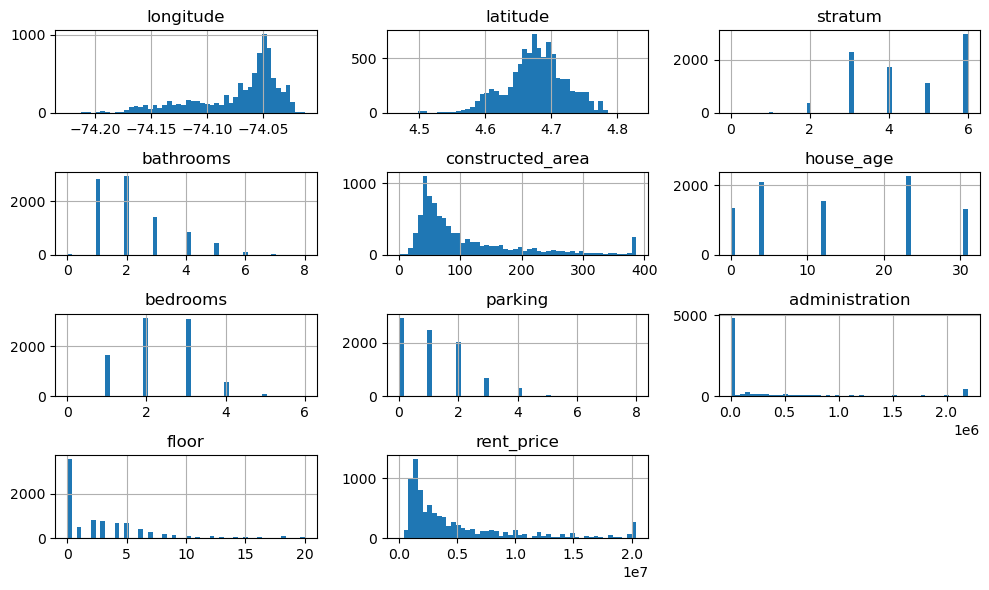

In [ ]:
data.hist(bins=50, figsize=(10,6))
plt.tight_layout()
plt.show()

In [ ]:
# Con el paquete folium se pueden graficar los puntos de ubicación (latitude y longitude) de los apartamentos en el mapa y con 
# paquete branca se puede añadir una barra de color para identificar los apartamentos por su precio
colores = ['#440154', '#3b528b', '#21918c', '#5ec962', '#aadc32', '#fdae32', '#fde725']
min_val, max_val = data['rent_price'].min(), data['rent_price'].max()
colormap = cm.LinearColormap(
    colors=colores,
    vmin=min_val,
    vmax=max_val
)
mapa = folium.Map(location=[data['latitude'].mean(), data['longitude'].mean()], zoom_start=12)
colormap.caption = 'Precio del arriendo'
colormap.add_to(mapa)


for _, row in data[['latitude', 'longitude', 'rent_price']].iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=1,
        color=colormap(row['rent_price']),
        fill=True,
        fill_opacity=0.3
    ).add_to(mapa)

mapa

Los precios a lo largo de la ciudad se ven bastantes parejos con precios por debajo de los 3.5 millones pero hay una zona que resalta bastante y son la localidad de Usaquen y chapinero con precios superiores a 6 millones, llegando a tener los precios mas altos regristrados de hasta 20 millones.  
Tambien se puede identificar que entre mas hacia el nororiente se encuentra el apartamento mas incrementa el valor de la renta.

In [ ]:
geometry = [Point(xy) for xy in zip(data['longitude'], data['latitude'])] #Se crean objetos tipo Point con los datos de longitude y latitude, para ubicarlo en las coordenadas

#Se crea un nuevo DataFrame que contiene los puntos de ubicacion. crs especifica el sistema de referencia de coordenadas
gdf_apartments = gpd.GeoDataFrame(data, geometry=geometry, crs='EPSG:4326')

#Archivo localidades_Bogota.json obtenido en la pagina del distrito de Bogota
localidades = gpd.read_file('../data/localidades_Bogota.json')
localidades = localidades.to_crs("EPSG:4326")
#sjoin identifica en que poligono(localidad) se encuentra el punto apartamento para añadir la localidad a los datos
gdf_resultado = gpd.sjoin(gdf_apartments, localidades[['geometry', 'LocNombre']], how='left', predicate='within')
data_localidad = data.copy()
data_localidad['Localidad'] = gdf_resultado['LocNombre']

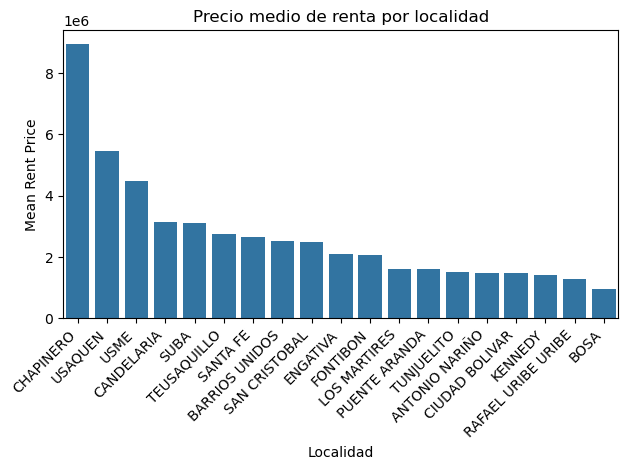

In [ ]:
#Agrupamiento del precio medio de arriendo por localidad
mean_price_localidad = data_localidad.groupby('Localidad')['rent_price'].mean().sort_values(ascending=False)
sns.barplot(mean_price_localidad)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Rent Price')
plt.title('Precio medio de renta por localidad')
plt.tight_layout()
plt.show()

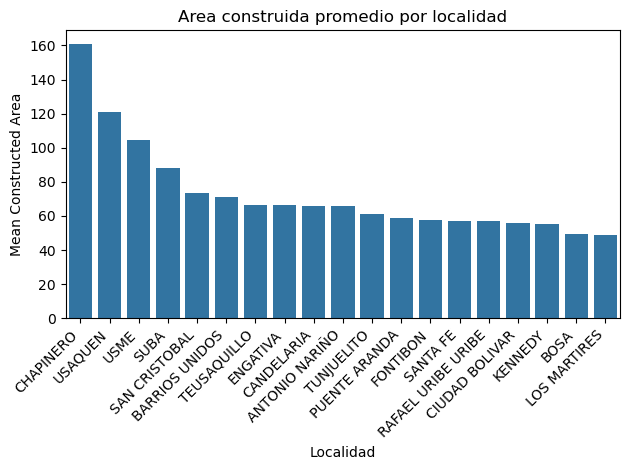

In [ ]:
mean_constructed_area_localidad = data_localidad.groupby('Localidad')['constructed_area'].mean().sort_values(ascending=False)
sns.barplot(mean_constructed_area_localidad)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Constructed Area')
plt.title('Area construida promedio por localidad')
plt.tight_layout()
plt.show()

Como se observo previamente en el mapa los bariios con precios mas elevados son chapinero e Usaquen, el resto de localidades tienen un precio mas parejo entre ellas

#### <font color=#A0A0A0>**🧹 Preprocesamiento y Selección de Caracteristicas**</font>

In [ ]:
#Transformacion de variable facilities que esta en formato string a formato array
data['facilities'] = data['facilities'].apply(ast.literal_eval)

In [ ]:
#Se contabilizan las comodidades mas comunes en data set 
facilities = {}
for i in data['facilities']:
    for j in i:
        facilities[j] = facilities.get(j, 0) + 1

n_rows = data.shape[0]
#Ahora se identificaran las comodidades menos comunes para descartarlas de los  (presencia inferior al 10%)
low_importance_facilities = []
for i in facilities:
    if (facilities[i]/n_rows) <= 0.1:
        low_importance_facilities.append(i) 
print(low_importance_facilities)

['Caldera', 'Loft', 'Patio', 'Acceso Pavimentado', 'Baño Independiente', 'Alarma', 'Cerca de Zona Urbana', 'Cochera', 'Jardín', 'Cancha de Squash', 'Duplex', 'Oficina de negocios', 'Sala de internet', 'Baño compartido', 'Baños comunales', 'Baños Públicos', 'Cocina Equipada', 'Sauna / Turco / Jacuzzi', 'Seguridad', 'Zona de BBQ', 'Vivienda Multifamiliar', 'Alcantarillado', 'Comedor auxiliar', 'Aire Acondicionado', 'Sensor de movimiento', 'Garaje / Parqueadero(s)', 'Garaje Cubierto', 'Piscina', 'Portería / Vigilancia', 'Servicios independientes', 'Ubicada en edificio', 'Salón de Juegos', 'Asador', 'Bombas de gasolina', 'Despensa', 'Con casa club', 'En condominio', 'Bahía exterior de parqueo', 'Cancha de Tennis', 'Escalera de Emergencia', 'Vivienda Bifamiliar', 'Cuarto de Escoltas', 'Jaula de Golf', 'En Edificio', 'En zona Comercial', 'Piso de alta resistencia', 'Árboles frutales', 'Cableado de Red', 'Puerta de seguridad', 'En centro Comercial', 'Servicio de Internet', 'PentHouse', 'Zona 

In [ ]:
data_localidad['localidad'].value_counts()

NameError: name 'data_localidad' is not defined

In [ ]:
# removiendo las keys con baja inportanca del dictionario facilities
for key_to_remove in low_importance_facilities:
    if key_to_remove in facilities: 
        del facilities[key_to_remove]

len(facilities)

54

In [35]:
#Eliminación de las variables con baja presencia de la variables facilities para crear las nuevas columnas en el dataset
data['facilities'] = data['facilities'].apply(lambda lista: [item for item in lista if item not in low_importance_facilities ])

In [36]:
# Se crearon y añadieron todas la columnas de comodidades encontradas al dataset
new_cols = pd.DataFrame(0, index=data.index, columns=list(facilities.keys()))
data = pd.concat([data, new_cols], axis=1)
data.shape

(8561, 66)

In [37]:
#Se asigna el valor 1 a las columnas que estan en la lista de facilities
for idx, i in enumerate(data['facilities']):
    for j in i:
        data.at[idx, j] = 1
data = data.drop(columns=['facilities'])

In [38]:
#Identificacion de variables con una correlacion mayor al 80%
df_facilities = data[facilities.keys()]
corr_facilities = df_facilities.corr().abs()
mask = np.triu(np.ones(corr_facilities.shape), k=1).astype(bool)
corr_features = corr_facilities.where(mask)
high_corr = [column for column in corr_features.columns if any(corr_features[column].abs()>0.8)]
print(high_corr)

['Ventilación Natural']


In [39]:
#Elimination of high correlated features
data = data.drop(columns=high_corr)

Con el objetivo de reducir mas el tamaño del dataset se va utilizar el metodo de Información Mutua (MI) que mide cuánta informacion comparte una variable X con un variable Y, es decir que tanto saber el valor X reduce la incertidumbre sobre Y

In [40]:
data = data.dropna(how='any')

In [41]:
X = data.drop(columns=['rent_price'])
y = data['rent_price']
mi_scores = mutual_info_regression(X, y)
mi_series = pd.Series(mi_scores, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

<Axes: >

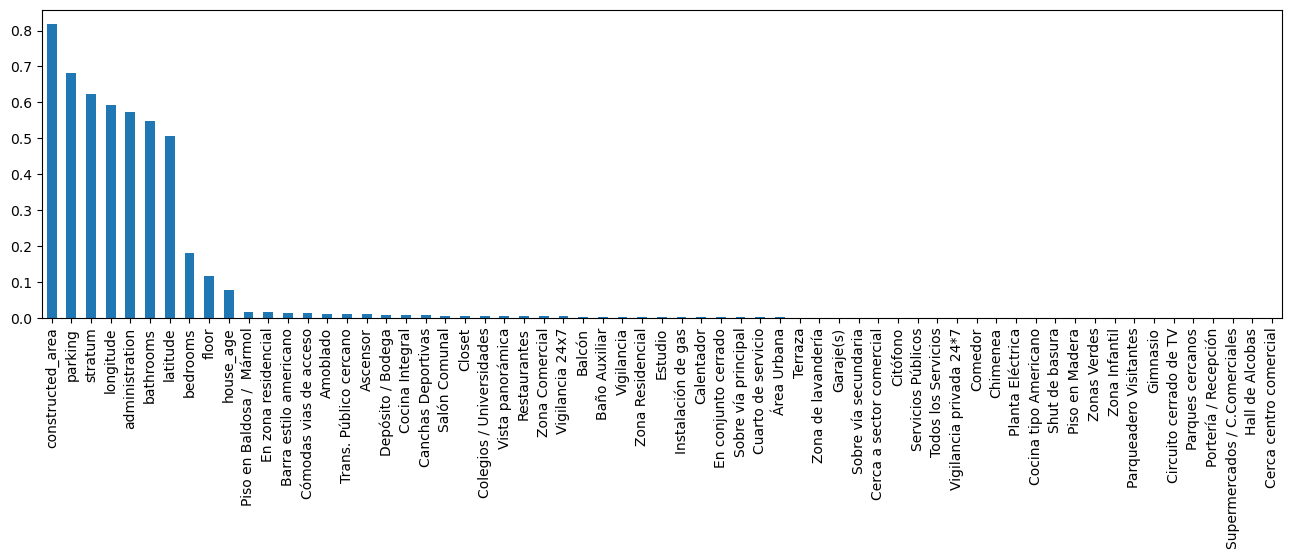

In [42]:
#Grafico para visualizar las variables mas relevantes o con mas poder predictivo
mi_series.plot(kind='bar', figsize=(16, 4))

Como se puede ver en la grafica casi todas las variables correspodientes a comodidades tiene casi un poder predictivo de 0. Por lo tanto solo se utilizaran variables que este por encima de un umbral de 0.05 (5%).

In [43]:
low_ml = mi_series[mi_series<0.05].index
data = data.drop(columns=low_ml)

In [44]:
data.head()

,longitude,latitude,stratum,bathrooms,constructed_area,house_age,bedrooms,parking,administration,floor,rent_price
0,-74.048398,4.700991,5.0,2.0,97.0,12.0,2.0,2.0,0.0,0.0,4500000.0
1,-74.055693,4.687506,6.0,1.0,42.0,12.0,1.0,1.0,0.0,5.0,2800000.0
2,-74.052512,4.675927,6.0,4.0,116.0,23.0,4.0,2.0,0.0,7.0,5500000.0
3,-74.049210,4.672860,5.0,3.0,138.0,23.0,3.0,2.0,0.0,4.0,8000000.0
4,-74.050727,4.700429,5.0,2.0,78.0,23.0,3.0,1.0,0.0,3.0,4000000.0


In [45]:
X = data.drop(columns=['rent_price'])
y = data['rent_price']

In [46]:
continuos_features = ['longitude', 'latitude', 'constructed_area', 'house_age', 'administration', 'floor','stratum', 'bathrooms', 'bedrooms', 'parking']

#### <font color=#A0A0A0> **🤖 Modeling and Machine learning**</font>

In [47]:
preprocessor = ColumnTransformer(transformers=[
    ('cont', StandardScaler(), continuos_features)
])

In [48]:
models = {
    'LinearRegression': LinearRegression(),
    'LassoCV': LassoCV(cv=5),
    'RandomForest':RandomForestRegressor(random_state=42),
    'XGBoost':  XGBRegressor(n_estimator=100, random_state = 42, verbosity=0)
}

In [49]:
#Se itera sobre la variable models para probar cada modelos e identificar el que tenga mayor rendimiento
def models_fit(models, X, y, preprocessor):
    results = []
    
    for name, model_instance in models.items():
        pipe = Pipeline(steps = [
            ('preprocessor', preprocessor),
            ('regressor', model_instance)
        ])
        
        scores  = cross_val_score(pipe, X, y,  cv=5, scoring='neg_root_mean_squared_error')
        results.append({
            'Model': name,
            'RMSE Mean': -np.mean(scores),
            'RSME Std': np.std(scores)
        })
    results_df = pd.DataFrame(results).sort_values(by = 'RMSE Mean')    
    return results_df

model_results = models_fit(models, X, y, preprocessor)
print(model_results)

              Model     RMSE Mean       RSME Std
3           XGBoost  1.712468e+06   95403.742644
2      RandomForest  1.724811e+06  102536.007085
0  LinearRegression  2.066443e+06   97564.781750
1           LassoCV  2.066493e+06   97411.108760


In [50]:
#Busqueda de mejor rendimiento en el modelo RandomForest combinando los diferente hiperparametros
param_grid_rf = {
    'regressor__n_estimators': [200, 300, 400],
    'regressor__max_depth': [None, 20, 30],
    'regressor__min_samples_split': [2, 5, 7]
}

grid_search_rf = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    param_grid_rf, 
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search_rf.fit(X, y)
print(f"Best RMSE: {-grid_search_rf.best_score_:.2f}")
print("Best params:", grid_search_rf.best_params_)

Best RMSE: 1712278.53
Best params: {'regressor__max_depth': 20, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 400}


In [ ]:
#Busqueda de mejor rendimiento en el modelo XGBoost combinando los diferente hiperparametros
param_grid_xgb = {
    'regressor__n_estimators': [200, 300],
    'regressor__learning_rate': [0.01, 0.05],
    'regressor__max_depth':[5, 8],
    'regressor__subsample':[0.8,1],
    'regressor__colsample_bytree': [0.8,1],
    'regressor__reg_lambda': [1,2]
}

grid_search_xgb = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(n_estimators =100, random_state=42, verbosity=0))
    ]),
    param_grid_xgb, 
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1)

grid_search_xgb.fit(X, y)
best_index = grid_search_xgb.best_index_
std_rmse = grid_search_xgb.cv_results_['std_test_score'][best_index]

print(f"Best RMSE: {-grid_search_xgb.best_score_:.2f}")
print("Best params:", grid_search_xgb.best_params_)
print("Best score (std_RMSE):", std_rmse)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best RMSE: 1642774.74
Best params: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 8, 'regressor__n_estimators': 200, 'regressor__reg_lambda': 1, 'regressor__subsample': 0.8}
Best score (std_RMSE): 112648.96978836111


Hasta el momento el modelo XGBoost es el mejor, el uso de grid_search para permutar los hiperparametros mejoro bastante el rendimiento del modelo.  
Con la mejor combinación de hiperparametros identificados se puede realizar el entrenamiento del modelo con los datos de entrenamiento y evaluar el poder predictivo del modelo con los datos de prueba.

In [52]:
#Ahora es momento de medir el poder predictivo del modelo obtenido evaluando dos metricas, la raiz del error medio cuadrado y el corf de determinación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model = grid_search_xgb.best_estimator_

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE test: {rmse:.2f}')
print(f'MAE test: {mae:.2f}')
print(f'R2 test: {r2:.2f}')

RMSE test: 1614593.77
MAE test: 839132.70
R2 test: 0.89


#### <font color=#A0A0A0> **🤖 Results and Evaluation**</font>

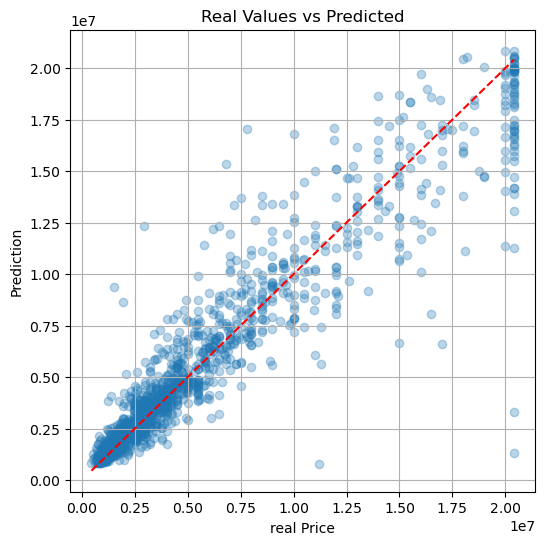

In [53]:
#Graficación de la correlacion entre el precio real y le predicho
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("real Price")
plt.ylabel("Prediction")
plt.title("Real Values vs Predicted")
plt.grid(True)
plt.show()

Hay una clara relación lineal entre los valores reales y predichos. Algo que se pupede destacar de la grafica es que a medida que incrementa el precio del apartamento es mas dificil para el modelo redecir el precio por lo tanto la grafica se torna mas dispersa. Graficar las distribucion de errores es otra forma de visualizar que tan bien el modelo predice los precios.

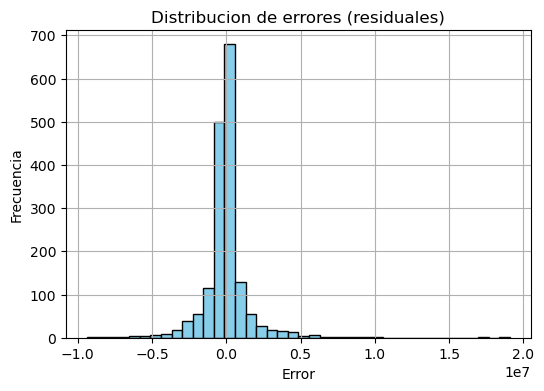

In [54]:
# Grafica de distribucion de los residuales

residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribucion de errores (residuales)')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

Como se pudo observar en la grafica anterior el modelo tiene buen poder predicto como indica la distribucion de errores, la mayoria de estos se agrupan alrededor de cero con una desviacion de alrededor de 900.000

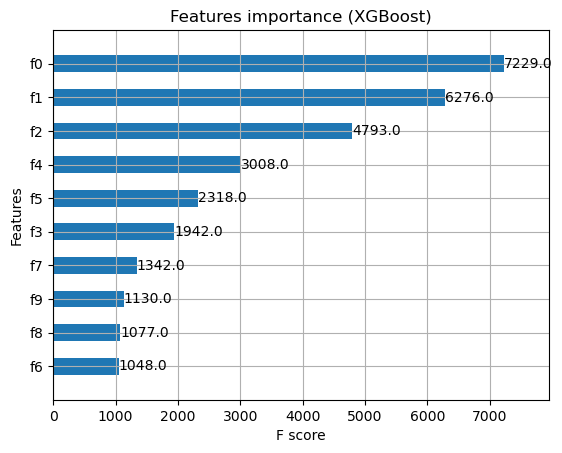

In [55]:
#El modelo xgboost tiene la capacidad de graficar los features mas importantes para el modelo. 
# Esto es util para descartar features que no aporten mucho al modelo y en cambio generen ruido.
xgb_model = best_model.named_steps['regressor']
plot_importance(xgb_model, max_num_features=12, height=0.5)
plt.title('Features importance (XGBoost)')
plt.show()

In [56]:
index_labels = ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']
features_importance = pd.DataFrame(continuos_features, index=index_labels, columns=['feature'])
features_importance

,feature
f0,longitude
f1,latitude
f2,constructed_area
f3,house_age
f4,administration
f5,floor
f6,stratum
f7,bathrooms
f8,bedrooms
f9,parking


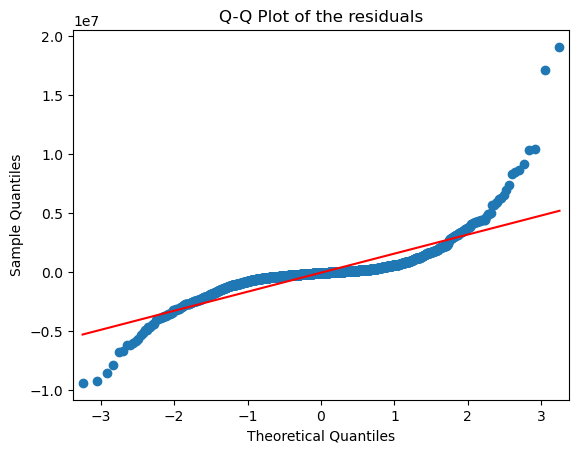

In [57]:
#El grafico Q.Q es bueno para mostrar si los errores del modelo siguen una distribucion normal
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of the residuals')
plt.show()

Cuando se utilizan un modelo lineal es importante que el modelo siga una distribucion normal. Pero no es el caso de XGBoost porque este modelo puede manejar relacion no lineales. Este comportamiento de la grafica Q-Q ya se veia reflejado en el grafico predicted vs real en donde se veia que entre mas altos eran los precios de la vivienda los datos se volvian mas dispersos y dificiles de predecir.

#### <font color=#A0A0A0> **🧐✅ Conclusions**</font>

Este proyecto abordó el problema de la predicción de precios de arriendo en la ciudad de Bogotá, utilizando datos extraídos mediante técnicas de Web Scraping a partir de la plataforma Finca Raíz. Se recolectaron 8.566 registros de apartamentos, cada uno con información clave como ubicación (latitud y longitud), área construida, estrato, número de parqueaderos, piso, número de habitaciones, entre otras variables relevantes. Además, se identificaron características adicionales ofrecidas por los arrendatarios, tales como cocina integral, amoblado, cercanía a vías principales y centros comerciales.

Se graficaron las caracteristicas obtenidas para identificar outliers y valores atipicos. Con la ayuda del dato de latitude y longitude se identifico facilmente la ubicación de estos apartamentos en el mapa con ayuda del paquete folium. En la busqueda de identificar a que localidad pertenecia cada propiedad, se encontro en la pagina del distrito de Bogota los poligonos de delimitación correspondientes a las localidades de Bogotá. Con este datos se clasificaron los apartamento por localidad y se ranquearon por precio de renta.

En el proceso de feature ingeniering se encontro que todas las features de comodidades extraidas no tenian un buen poder predictivo sobre la variable objetivo, con ayuda del metodo información de sklearn se descartaron las variables con una influencia inferior al 5%, en donde todas las features de comodidades fueron descartadas, dejando solamente variables continuas que fueron escaladas en el preprocesamiento.

El modelo con el mejor rendimiento fue XGBoost con un R² de 0.89, que es un buen valor, pero puede verse mejorado si se entrena el con apartamentos con rentas menores a 10 millones. En el grafico de renta predecida vs real se puede observar como las propiedades con rentas inferiores a 8 millones tienen menos dispersion y predicen mejor el valor, los precios superiores se vuelven mas dispersos y dificiles de predecir.

Como mejoras del proyecto a futuro se pueden obtener ubicaciones de lugares de interes del comprador, como hospitales, parques, universidades, lugar de trabajo etc. Con el fin de darle al usuario una recomendación o las mejores opciones para arrendar apartamento de acuerdo a su capacidad economica y preferencias.